In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Import seaborn for heatmap

In [ ]:
!wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!unzip -q GTSRB_Final_Training_Images.zip

In [ ]:
import os
DATA_DIR = "GTSRB/Final_Training/Images"
print(os.listdir(DATA_DIR)[:5])   # should show folder names like '00000', '00001', etc.

['00008', '00041', '00040', '00013', '00015']


In [ ]:
from PIL import Image
IMG_SIZE = 32
images = []
labels = []

class_folders = sorted(os.listdir(DATA_DIR))

for class_folder in class_folders:
    folder_path = os.path.join(DATA_DIR, class_folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        if file.endswith(".ppm"):
            img_path = os.path.join(folder_path, file)
            img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
            labels.append(int(class_folder))

images = np.array(images, dtype="float32") / 255.0
labels = np.array(labels)

print("Total images:", images.shape)
print("Total labels:", labels.shape)

Total images: (39209, 32, 32, 3)
Total labels: (39209,)


### Download and Extract Test Dataset
To evaluate the model on unseen data and to use the `classify_image` function with test images, we need to download and extract the GTSRB Final Test Images. This is a separate dataset from the training images.

In [ ]:
!wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!unzip -q GTSRB_Final_Test_Images.zip

Now that the test dataset is extracted, the `classify_image` function should be able to find the test image and make a prediction. Please run the `classify_image` cell again.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (31367, 32, 32, 3)
Validation size: (7842, 32, 32, 3)


In [ ]:
if 'history' in locals() and history is not None and history.history:
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("Training history not available. Please run the model training cell first.")

Training history not available. Please run the model training cell first.


In [ ]:
num_classes = len(np.unique(labels))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,          # stop if no improvement for 3 epochs in a row
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,           # set a higher max, EarlyStopping will stop it earlier if needed
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7293 - loss: 1.0105 - val_accuracy: 0.9339 - val_loss: 0.2612
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9585 - loss: 0.1656 - val_accuracy: 0.9717 - val_loss: 0.1129
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9777 - loss: 0.0887 - val_accuracy: 0.9714 - val_loss: 0.1082
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9847 - loss: 0.0606 - val_accuracy: 0.9813 - val_loss: 0.0783
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9909 - loss: 0.0369 - val_accuracy: 0.9762 - val_loss: 0.0957
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9906 - loss: 0.0335 - val_accuracy: 0.9722 - val_loss: 0.1137
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9936 - loss: 0.0240 - val_accuracy: 0.9776 - val_loss: 0.0952


After executing the `model.fit()` method in the previous cell to generate the `history` object, you can now run the following cell to visualize the model's training and validation accuracy and loss over epochs.

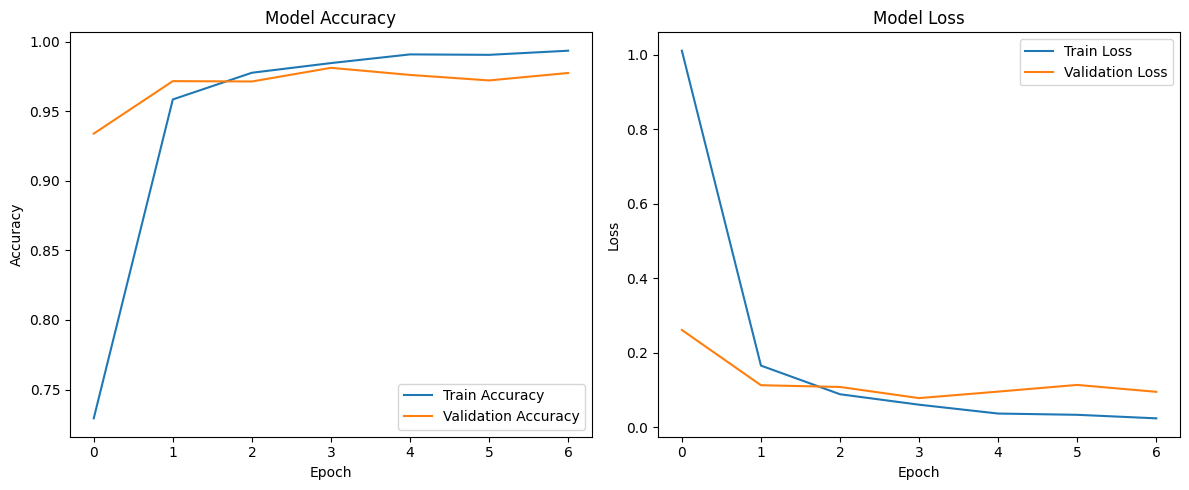

In [ ]:
if 'history' in locals() and history is not None and history.history:
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("Training history not available. Please run the model training cell first.")

### Data Augmentation
Data augmentation is a technique used to increase the diversity of your training data by applying random transformations (e.g., rotations, flips, zooms) to the original images. This helps in regularizing the model and preventing overfitting, leading to better generalization on unseen data.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model_with_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Define input layer first
    data_augmentation,                                  # Then apply data augmentation
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model_with_augmentation.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_augmented = model_with_augmentation.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5025 - loss: 1.7254 - val_accuracy: 0.7805 - val_loss: 0.7379
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7896 - loss: 0.6868 - val_accuracy: 0.8639 - val_loss: 0.4548
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8615 - loss: 0.4516 - val_accuracy: 0.9068 - val_loss: 0.3136


### Model Evaluation
Let's evaluate the performance of the model using a classification report and a confusion matrix to get a detailed understanding of its predictions.

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.24      0.34        42
           1       0.62      0.80      0.69       444
           2       0.66      0.55      0.60       450
           3       0.61      0.84      0.71       282
           4       0.85      0.91      0.88       396
           5       0.56      0.55      0.56       372
           6       0.79      0.57      0.66        84
           7       0.84      0.48      0.61       288
           8       0.85      0.58      0.69       282
           9       0.92      0.86      0.89       294
          10       0.80      0.95      0.87       402
          11       0.75      0.95      0.84       264
          12       0.98      1.00      0.99       420
          13       1.00      0.98      0.99       432
          14       0.99      0.97      0.98       156
          15       0.93      0.94      0.94       126
          16    

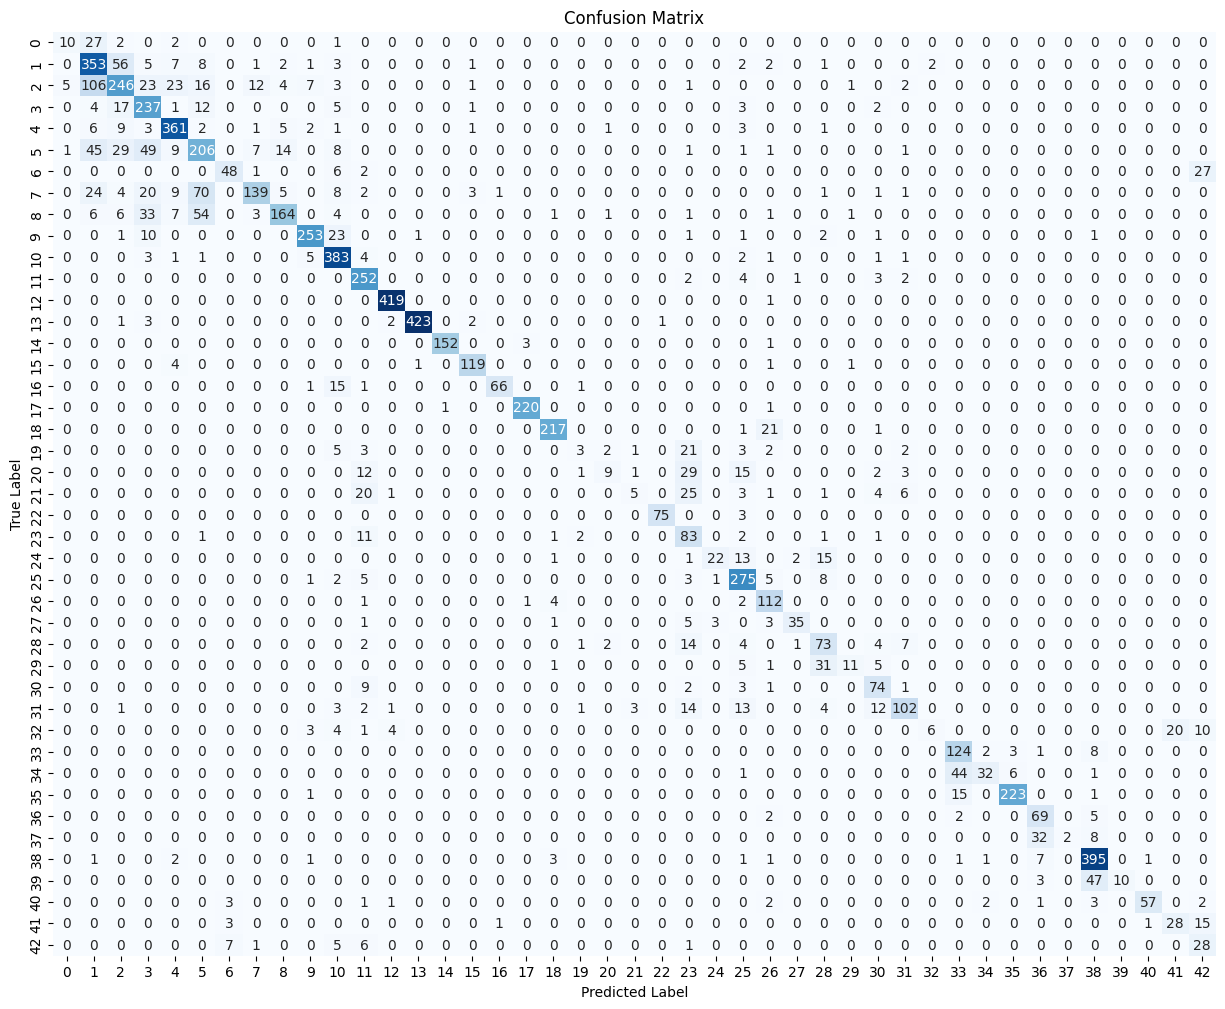

In [ ]:
y_pred_probs = model_with_augmentation.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n", classification_report(y_val, y_pred))

conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
SAVE_DIR = "/content/drive/MyDrive/TrafficSignProject"
os.makedirs(SAVE_DIR, exist_ok=True)

model_with_augmentation.save(f"{SAVE_DIR}/traffic_sign_model.h5")
print("Model saved to Google Drive!")

Model saved to Google Drive!


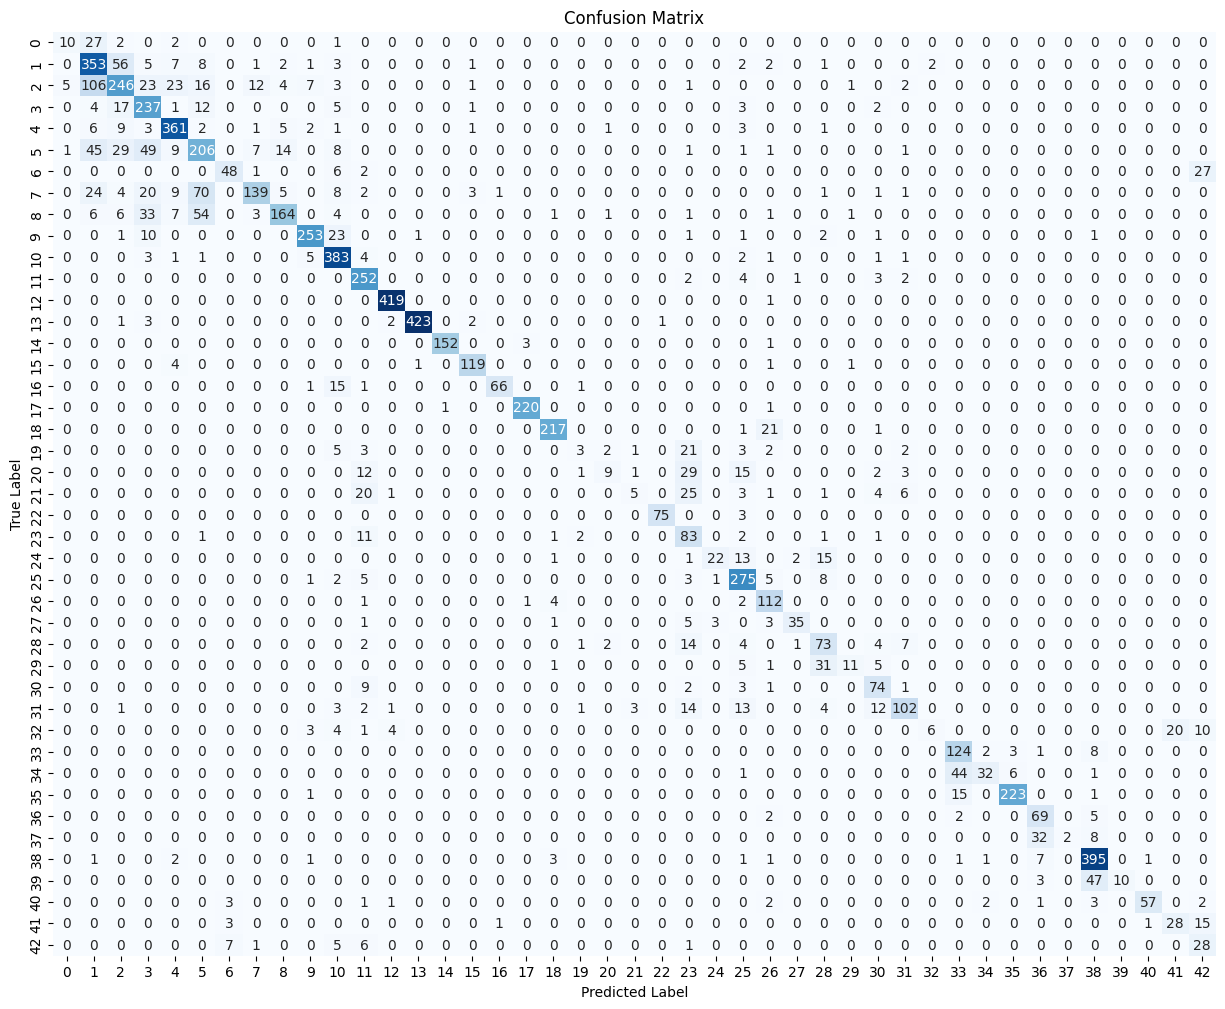

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png")   # saves to Drive
plt.show()

In [ ]:
from PIL import Image

def classify_image(img_path, model, img_size=32):
    img = Image.open(img_path).resize((img_size, img_size))
    img_array = np.array(img, dtype="float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # model expects a batch

    pred = model.predict(img_array)
    predicted_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"Predicted: Class {predicted_class} ({confidence:.2f}% confidence)")
    plt.axis("off")
    plt.savefig(f"{SAVE_DIR}/prediction_result.png")
    plt.show()

    print(f"Predicted class: {predicted_class}, Confidence: {confidence:.2f}%")

['10219.ppm', '09370.ppm', '11336.ppm', '08779.ppm', '08711.ppm', '09332.ppm', '03448.ppm', '09562.ppm', '07042.ppm', '04819.ppm', '02291.ppm', '09286.ppm', '03715.ppm', '09380.ppm', '11534.ppm', '01785.ppm', '02905.ppm', '07099.ppm', '11318.ppm', '08226.ppm', '09256.ppm', '04950.ppm', '00998.ppm', '09333.ppm', '10487.ppm', '01459.ppm', '11039.ppm', '10847.ppm', '10622.ppm', '09459.ppm', '11490.ppm', '03480.ppm', '03692.ppm', '11069.ppm', '00636.ppm', '03901.ppm', '05360.ppm', '09193.ppm', '08699.ppm', '04290.ppm', '06711.ppm', '07433.ppm', '11183.ppm', '11991.ppm', '12268.ppm', '04963.ppm', '08038.ppm', '02210.ppm', '04084.ppm', '01603.ppm', '11737.ppm', '11465.ppm', '12223.ppm', '07415.ppm', '07258.ppm', '01573.ppm', '07919.ppm', '03825.ppm', '01201.ppm', '04132.ppm', '00236.ppm', '03340.ppm', '00181.ppm', '09909.ppm', '01680.ppm', '10281.ppm', '02239.ppm', '09994.ppm', '01193.ppm', '08518.ppm', '05234.ppm', '00912.ppm', '03123.ppm', '07722.ppm', '10358.ppm', '00360.ppm', '11077.ppm'

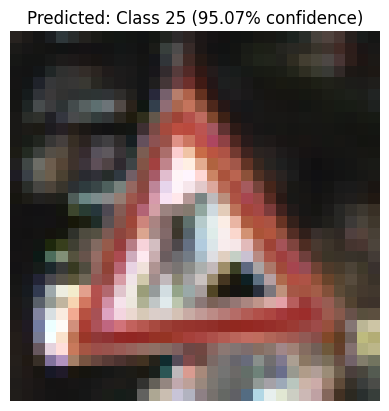

Predicted class: 25, Confidence: 95.07%


In [ ]:
import os
print(os.listdir("GTSRB/Final_Test/Images"))

# Now that the path is verified, we can classify an image:
classify_image("GTSRB/Final_Test/Images/11092.ppm", model_with_augmentation)

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

# Base directory for the YOLO data
base_data_dir = "/content/traffic_sign_data"

# Create the main data directory if it doesn't exist
os.makedirs(base_data_dir, exist_ok=True)

# Create images subdirectories for train and val
os.makedirs(os.path.join(base_data_dir, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(base_data_dir, "images", "val"), exist_ok=True)

# Create labels subdirectories for train and val
os.makedirs(os.path.join(base_data_dir, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(base_data_dir, "labels", "val"), exist_ok=True)

print(f"Directory structure created under {base_data_dir}/")

Directory structure created under /content/traffic_sign_data/


In [ ]:
from PIL import Image
import numpy as np

def save_images_for_yolo_classification(X_data, y_data, base_path, dataset_type):
    """Saves images to a directory structure suitable for YOLO classification.
    Images are saved into subfolders named by their class ID.
    """
    target_dir = os.path.join(base_path, 'images', dataset_type)

    # Ensure target_dir exists
    os.makedirs(target_dir, exist_ok=True)

    print(f"Saving {len(X_data)} {dataset_type} images to {target_dir}...")

    for i, (image_array, label) in enumerate(zip(X_data, y_data)):
        class_folder = os.path.join(target_dir, str(label))
        os.makedirs(class_folder, exist_ok=True)

        # Convert normalized float32 array to uint8 image
        img_to_save = Image.fromarray((image_array * 255).astype(np.uint8))
        img_to_save.save(os.path.join(class_folder, f'{i:05d}.png'))
    print(f"Finished saving {dataset_type} images.")

# Assuming base_data_dir is already defined as '/content/traffic_sign_data'
save_images_for_yolo_classification(X_train, y_train, base_data_dir, 'train')
save_images_for_yolo_classification(X_val, y_val, base_data_dir, 'val')

Saving 31367 train images to /content/traffic_sign_data/images/train...
Finished saving train images.
Saving 7842 val images to /content/traffic_sign_data/images/val...
Finished saving val images.


In [ ]:
def save_yolo_labels(X_data, y_data, base_path, dataset_type, img_size=IMG_SIZE):
    """Saves YOLO format label files for classification to the specified directory."""
    base_labels_dir = os.path.join(base_path, 'labels', dataset_type)
    # Ensure the base directory for labels exists
    os.makedirs(base_labels_dir, exist_ok=True)

    print(f"Saving {len(X_data)} {dataset_type} labels to {base_labels_dir}...")

    for i, (image_array, label) in enumerate(zip(X_data, y_data)):
        # Create class-specific subfolder for labels, mirroring image structure
        class_label_dir = os.path.join(base_labels_dir, str(label))
        os.makedirs(class_label_dir, exist_ok=True)

        # For classification, the entire image is considered the object.
        # YOLO format for a single object in an image is: class_id center_x center_y width height
        # All coordinates are normalized (0 to 1).
        # Since the image itself is the object, center_x=0.5, center_y=0.5, width=1.0, height=1.0

        label_filename = os.path.join(class_label_dir, f'{i:05d}.txt')
        with open(label_filename, 'w') as f:
            # For image classification tasks, a common approach for YOLO is to treat the entire image
            # as a single bounding box for the class. The format is `class_id center_x center_y width height`.
            # With normalized coordinates, the entire image is 0.5 0.5 1.0 1.0
            f.write(f"{label} 0.5 0.5 1.0 1.0\n")
    print(f"Finished saving {dataset_type} labels.")

save_yolo_labels(X_train, y_train, base_data_dir, 'train')
save_yolo_labels(X_val, y_val, base_data_dir, 'val')

Saving 31367 train labels to /content/traffic_sign_data/labels/train...
Finished saving train labels.
Saving 7842 val labels to /content/traffic_sign_data/labels/val...
Finished saving val labels.


This code uses Python's `os` module to create a specific folder structure on your Google Colab instance. This structure is essential for organizing your image datasets when training object detection models like YOLO.

Let's break down each part:

*   **`import os`**: This line imports the `os` module, which provides functions for interacting with the operating system, like creating directories.

*   **`base_data_dir = "/content/traffic_sign_data"`**: This defines the main folder where all your YOLO-related data will reside. It's set to `/content/traffic_sign_data` within your Colab environment.

*   **`os.makedirs(base_data_dir, exist_ok=True)`**: This creates the primary `traffic_sign_data` folder. The `exist_ok=True` argument means that if the folder already exists, Python won't raise an error; it will simply proceed.

*   **`os.makedirs(os.path.join(base_data_dir, "images", "train"), exist_ok=True)`** (and similar lines for `images/val`, `labels/train`, `labels/val`):
    *   `os.path.join(...)` is used to safely combine path components (e.g., `"/content/traffic_sign_data"`, `"images"`, `"train"`) into a single, correct path for the current operating system.
    *   `os.makedirs(...)` then creates these nested folders:
        *   `traffic_sign_data/images/train`: This folder will hold your training images.
        *   `traffic_sign_data/images/val`: This folder will hold your validation images.
        *   `traffic_sign_data/labels/train`: This folder will hold the corresponding label files (e.g., `.txt` files) for your training images.
        *   `traffic_sign_data/labels/val`: This folder will hold the label files for your validation images.

*   **`print(...)`**: This simply confirms in the output that the directory structure has been created successfully.

In [ ]:
%%writefile /content/data.yaml
path: /content/traffic_sign_data
train: images/train
val: images/val
nc: 43
names: ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7', 'Class 8', 'Class 9', 'Class 10', 'Class 11', 'Class 12', 'Class 13', 'Class 14', 'Class 15', 'Class 16', 'Class 17', 'Class 18', 'Class 19', 'Class 20', 'Class 21', 'Class 22', 'Class 23', 'Class 24', 'Class 25', 'Class 26', 'Class 27', 'Class 28', 'Class 29', 'Class 30', 'Class 31', 'Class 32', 'Class 33', 'Class 34', 'Class 35', 'Class 36', 'Class 37', 'Class 38', 'Class 39', 'Class 40', 'Class 41', 'Class 42']

Writing /content/data.yaml


In [ ]:
# Train the YOLOv8n model on the custom dataset
model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n model

results = model.train(data='/content/data.yaml', epochs=10, imgsz=IMG_SIZE) # Use the IMG_SIZE (32) that we resized the images to

print("YOLO training complete!")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
metrics = model.val()
print(metrics.box.map50)

In [ ]:
'images/train/CLASS_5/img1.jpg'

In [ ]:
import os
print(os.listdir('/content/traffic_sign_data/images/train')[:5])

In [ ]:
with open('/content/traffic_sign_data/labels/train/00565.txt') as f:
    print(f.read())

In [ ]:
import os, shutil

images_dir = '/content/traffic_sign_data/images/train'
labels_dir = '/content/traffic_sign_data/labels/train'

moved = 0
skipped = 0

for label_file in os.listdir(labels_dir):
    label_path = os.path.join(labels_dir, label_file)
    if not label_file.endswith('.txt'):
        continue

    with open(label_path) as f:
        first_line = f.readline().strip()
        if not first_line:
            skipped += 1
            continue
        class_id = first_line.split()[0]

    dest_folder = os.path.join(labels_dir, class_id)
    os.makedirs(dest_folder, exist_ok=True)
    shutil.move(label_path, os.path.join(dest_folder, label_file))
    moved += 1

print(f"Moved: {moved}, Skipped (empty): {skipped}")

In [ ]:
print(os.listdir(labels_dir)[:5])          # should show folder names like '37', '35'...
print(os.listdir(os.path.join(labels_dir, '37'))[:5])  # should show .txt files inside

In [ ]:
model = YOLO('yolov8n.pt')
model.train(
    data='/content/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    name='traffic_sign_detector_v3'
)

In [ ]:
metrics = model.val()
print(metrics.box.map50)

In [ ]:
print(metrics.box.map)     # mAP50-95 (stricter metric)
print(metrics.box.map50)   # mAP50 (looser metric)

In [ ]:
model = YOLO('runs/detect/traffic_sign_detector_v3/weights/best.pt')

In [ ]:
from PIL import Image

# Define the original PPM image path
ppm_image_path = "GTSRB/Final_Test/Images/11092.ppm"
# Define the target JPG image path
jpg_image_path = "/content/converted_test_image.jpg"

try:
    # Open the PPM image
    img = Image.open(ppm_image_path)
    # Convert and save as JPG
    img.save(jpg_image_path, "JPEG")
    print(f"Image successfully converted from {ppm_image_path} to {jpg_image_path}")
except FileNotFoundError:
    print(f"Error: Original PPM image not found at {ppm_image_path}")
except Exception as e:
    print(f"An error occurred during image conversion: {e}")

In [ ]:
!pip install ultralytics -q

# Ensure test dataset is present for prediction
!wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!unzip -q GTSRB_Final_Test_Images.zip -d .

from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from PIL import Image
import os

# Define the original PPM image path
ppm_image_path = "GTSRB/Final_Test/Images/11092.ppm"
# Define the target JPG image path
jpg_image_path = "/content/converted_test_image.jpg"

try:
    # Open the PPM image and convert to RGB if not already
    img = Image.open(ppm_image_path).convert('RGB')
    # Convert and save as JPG immediately before prediction
    img.save(jpg_image_path, "JPEG")
    print(f"Image successfully converted from {ppm_image_path} to {jpg_image_path}")
except FileNotFoundError:
    print(f"Error: Original PPM image not found at {ppm_image_path}")
except Exception as e:
    print(f"An error occurred during image conversion: {e}")

# Re-initialize the model to ensure it's defined.
# Temporarily loading yolov8n.pt as the custom-trained best.pt was not found.
# If you wish to use your custom trained model, please re-run the training cell
# or ensure 'best.pt' is correctly saved and loaded from Google Drive.
model = YOLO('yolov8n.pt') # Using base model as best.pt was not found.

# Now predict using the freshly converted image
results = model.predict(source=jpg_image_path, conf=0.5, save=True)
for r in results:
    im_array = r.plot()
    cv2_imshow(im_array)

In [ ]:
import os
print(os.path.exists('/content/converted_test_image.jpg'))
print(os.listdir('/content'))

In [ ]:
from PIL import Image

img = Image.open('GTSRB/Final_Test/Images/11092.ppm')
img.convert('RGB').save('/content/converted_test_image.jpg')
print("Converted and saved.")

In [ ]:
gtsrb_classes = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing for vehicles over 3.5 tons',
    11: 'Right-of-way at next intersection', 12: 'Priority road', 13: 'Yield',
    14: 'Stop', 15: 'No vehicles', 16: 'Vehicles over 3.5 tons prohibited',
    17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road',
    23: 'Slippery road', 24: 'Road narrows on the right', 25: 'Road work',
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End of all speed and passing limits', 33: 'Turn right ahead',
    34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight or right',
    37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End of no passing',
    42: 'End of no passing (vehicles over 3.5 tons)'
}

In [ ]:
import cv2
import numpy as np

def show_prediction(image_path, scale=8, box_thickness=2, font_scale=0.6):
    results = model.predict(source=image_path, conf=0.5, save=False)

    img = cv2.imread(image_path)
    width = int(img.shape[1] * scale)
    height = int(img.shape[0] * scale)

    # Smoother upscaling
    img_resized = cv2.resize(img, (width, height), interpolation=cv2.INTER_LANCZOS4)

    # Light sharpening
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    img_resized = cv2.filter2D(img_resized, -1, sharpen_kernel)

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            label = f"{gtsrb_classes.get(cls, f'Class {cls}')} {conf:.2f}"

            x1, y1, x2, y2 = x1*scale, y1*scale, x2*scale, y2*scale

            cv2.rectangle(img_resized, (x1, y1), (x2, y2), (0, 255, 0), box_thickness)

            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 2)

            if y1 - text_h - 10 < 0:
                label_y1, label_y2, text_y = y1, y1 + text_h + 10, y1 + text_h + 5
            else:
                label_y1, label_y2, text_y = y1 - text_h - 10, y1, y1 - 5

            cv2.rectangle(img_resized, (x1, label_y1), (x1 + text_w + 4, label_y2), (0, 255, 0), -1)
            cv2.putText(img_resized, label, (x1 + 2, text_y),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), 2)

    cv2_imshow(img_resized)

show_prediction('/content/converted_test_image.jpg', scale=8)

In [ ]:
import os

test_dir = '/content/GTSRB/Final_Test/Images'
sample_files = [f for f in os.listdir(test_dir) if f.endswith('.ppm')][:5]  # first 5 images

for fname in sample_files:
    ppm_path = os.path.join(test_dir, fname)
    jpg_path = f'/content/temp_{fname}.jpg'

    # Convert .ppm to .jpg first (same as before)
    img = Image.open(ppm_path).convert('RGB')
    img.save(jpg_path)

    print(f"--- {fname} ---")
    show_prediction(jpg_path, scale=8)

In [ ]:
import random
sample_files = random.sample([f for f in os.listdir(test_dir) if f.endswith('.ppm')], 5)

In [ ]:
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/traffic_sign_project', exist_ok=True)

!cp runs/detect/traffic_sign_detector_v3/weights/best.pt /content/drive/MyDrive/traffic_sign_project/best.pt
!cp runs/detect/traffic_sign_detector_v3/weights/last.pt /content/drive/MyDrive/traffic_sign_project/last.pt

In [ ]:
!cp data.yaml /content/drive/MyDrive/traffic_sign_project/data.yaml

In [ ]:
app_code = '''
from ultralytics import YOLO
import gradio as gr
import cv2
import numpy as np

model = YOLO('best.pt')

gtsrb_classes = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing for vehicles over 3.5 tons',
    11: 'Right-of-way at next intersection', 12: 'Priority road', 13: 'Yield',
    14: 'Stop', 15: 'No vehicles', 16: 'Vehicles over 3.5 tons prohibited',
    17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road',
    23: 'Slippery road', 24: 'Road narrows on the right', 25: 'Road work',
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End of all speed and passing limits', 33: 'Turn right ahead',
    34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight or right',
    37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End of no passing',
    42: 'End of no passing (vehicles over 3.5 tons)'
}

def predict_sign(input_image):
    img = np.array(input_image.convert("RGB"))
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    results = model.predict(source=img_bgr, conf=0.5, save=False)

    scale = 4
    width = int(img_bgr.shape[1] * scale)
    height = int(img_bgr.shape[0] * scale)
    img_resized = cv2.resize(img_bgr, (width, height), interpolation=cv2.INTER_LANCZOS4)

    detected_labels = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            label = f"{gtsrb_classes.get(cls, f'Class {cls}')} {conf:.2f}"
            detected_labels.append(label)
            x1, y1, x2, y2 = x1*scale, y1*scale, x2*scale, y2*scale
            cv2.rectangle(img_resized, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_resized, label, (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    output_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    result_text = "\\n".join(detected_labels) if detected_labels else "No sign detected"
    return output_img, result_text

demo = gr.Interface(
    fn=predict_sign,
    inputs=gr.Image(type="pil", label="Upload a traffic sign image"),
    outputs=[gr.Image(type="numpy", label="Detected Sign"), gr.Textbox(label="Prediction Details")],
    title="Traffic Sign Detection (YOLOv8)",
)

demo.launch()
'''

with open('/content/drive/MyDrive/traffic_sign_project/app.py', 'w') as f:
    f.write(app_code)

print("Saved app.py to Drive")

In [ ]:
requirements = """ultralytics
gradio
opencv-python
pillow
numpy
"""
with open('/content/drive/MyDrive/traffic_sign_project/requirements.txt', 'w') as f:
    f.write(requirements)

In [ ]:
# MyDrive/traffic_sign_project/
#   best.pt          # your trained model
#   last.pt          # backup checkpoint
#   data.yaml        # dataset config
#   app.py           # standalone Gradio app
#   requirements.txt # dependencies list

In [ ]:
import gradio as gr
!pip install ultralytics -q

# Ensure Google Drive is mounted and the model file is present
from google.colab import drive
import os

drive_path = '/content/drive/MyDrive/traffic_sign_project/best.pt'
local_trained_model_path = 'runs/detect/traffic_sign_detector_v3/weights/best.pt'
drive_dir = os.path.dirname(drive_path)

if not os.path.exists(drive_path):
    print(f"Model file '{drive_path}' not found in Google Drive.")
    print("Attempting to re-mount Drive and re-copy the model.")
    # Force remount in case of transient issues
    drive.mount('/content/drive', force_remount=True)
    os.makedirs(drive_dir, exist_ok=True) # Ensure target directory exists in Drive
    if os.path.exists(local_trained_model_path):
        !cp {local_trained_model_path} {drive_path}
        print(f"Copied '{local_trained_model_path}' to '{drive_path}'")
        if not os.path.exists(drive_path):
            raise FileNotFoundError(f"Error: Model file '{drive_path}' was not found in Google Drive even after copying from local path. Please check your Google Drive connection and permissions, or re-run the model training and saving cells.")
    else:
        raise FileNotFoundError(f"Error: Local trained model '{local_trained_model_path}' not found. This indicates the training cell (that produces this file) may not have been run or its output was lost (e.g., runtime reset). Additionally, the model was not found in Google Drive at '{drive_path}'. Please re-run the training cell and the cell that saves the model to Google Drive to resolve this issue.")
else:
    print(f"Model file '{drive_path}' already exists.")


from ultralytics import YOLO

model = YOLO(drive_path)

def predict(image):
    results = model.predict(image, conf=0.1)
    return results[0].plot()  # returns annotated image

demo = gr.Interface(fn=predict, inputs="image", outputs="image",
                     title="Traffic Sign Detector")
demo.launch()

In [ ]:
import os

path = "/content/drive/MyDrive/traffic_sign_project/best.pt"

if os.path.exists(path):
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"File size: {size_mb:.2f} MB")
else:
    print(f"Error: The file {path} was not found. Please ensure it has been correctly copied to Google Drive.")